# Nifty 100 Financial Intelligence Analysis

In [3]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("../db/nifty100.db")
companies = pd.read_sql("SELECT * FROM companies", conn)

sectors = pd.read_excel("../data/raw/sectors.xlsx", header=None)
sectors.columns = sectors.iloc[0]   
sectors = sectors[1:]         
sectors.columns = (
    sectors.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)     
print(companies.shape)
print(companies.columns)
print(sectors.columns)
companies.head()
sectors.head()


(92, 12)
Index(['id', 'company_logo', 'company_name', 'chart_link', 'about_company',
       'website', 'nse_profile', 'bse_profile', 'face_value', 'book_value',
       'roce_percentage', 'roe_percentage'],
      dtype='str')
Index(['id', 'company_id', 'broad_sector', 'sub_sector', 'index_weight_pct',
       'market_cap_category'],
      dtype='str', name=0)


,id,company_id,broad_sector,sub_sector,index_weight_pct,market_cap_category
1,1,ABB,Industrials,Capital Goods,0.81,Large Cap
2,2,ADANIENSOL,Energy,Power & Utilities,0.65,Large Cap
3,3,ADANIENT,Industrials,Conglomerates,1.5,Large Cap
4,4,ADANIGREEN,Energy,Renewable Energy,1.23,Large Cap
5,5,ADANIPORTS,Industrials,Infrastructure,2.12,Large Cap


In [4]:
companies.columns = companies.columns.str.lower()

merged = companies.merge(sectors, left_on="id", right_on="company_id")

merged.head()

,id_x,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage,id_y,company_id,broad_sector,sub_sector,index_weight_pct,market_cap_category
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90,1,ABB,Industrials,Capital Goods,0.81,Large Cap
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59,2,ADANIENSOL,Energy,Power & Utilities,0.65,Large Cap
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64,3,ADANIENT,Industrials,Conglomerates,1.5,Large Cap
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70,4,ADANIGREEN,Energy,Renewable Energy,1.23,Large Cap
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd\n,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10,5,ADANIPORTS,Industrials,Infrastructure,2.12,Large Cap


In [5]:
companies = pd.read_sql("SELECT * FROM companies", conn)

companies = companies.rename(columns={"id": "company_id"})

companies.head()

,company_id,company_logo,company_name,chart_link,about_company,website,nse_profile,bse_profile,face_value,book_value,roce_percentage,roe_percentage
0,ABB,https://mkt.in/static/mkt-icons/nifty100/ABB.png,Abbott India Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,Abbott India Ltd is one of the leading multina...,https://www.abbott.co.in/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/abb...,10.0,1657.0,46.0,34.90
1,ADANIENSOL,https://m.economictimes.com/thumb/msid-1173715...,Adani Energy Solutions Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"AESL, part of the Adani portfolio, is a multid...",https://www.adanienergysolutions.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,175.0,9.0,8.59
2,ADANIENT,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Enterprises Ltd,https://in.tradingview.com/chart/?symbol=ADANIENT,Adani Enterprises Ltd is an Indian multination...,https://www.adanienterprises.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,1.0,363.0,11.6,13.64
3,ADANIGREEN,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Green Energy Ltd,https://in.tradingview.com/chart/?symbol=NSE%3...,"Adani Green Energy Limited, incorporated in 20...",http://www.adanigreenenergy.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,10.0,67.0,96.5,14.70
4,ADANIPORTS,https://mkt.in/static/mkt-icons/nifty100/ADANI...,Adani Ports & Special Economic Zone Ltd\n,https://in.tradingview.com/chart/?symbol=NSE%3...,Adani Ports & Special Economic Zone is in the ...,http://www.adaniports.com/,https://www.nseindia.com/get-quotes/equity?sym...,https://www.bseindia.com/stock-share-price/ada...,2.0,265.0,12.9,18.10


 # SECTOR DISTRIBUTION

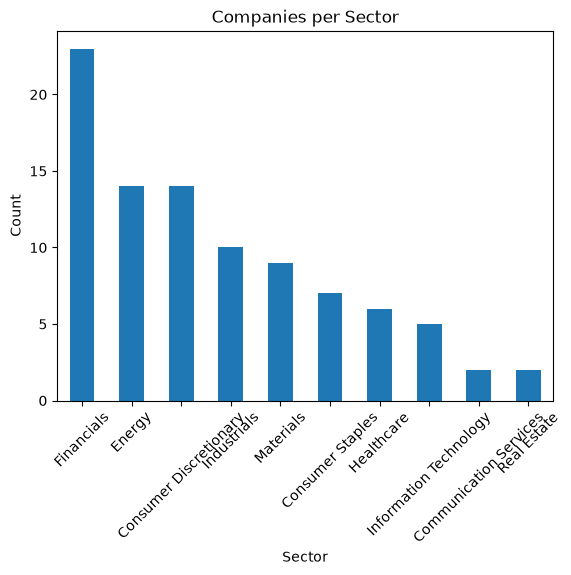

In [6]:
import matplotlib.pyplot as plt

sector_counts = merged['broad_sector'].value_counts()

sector_counts.plot(kind='bar')
plt.title("Companies per Sector")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# TOP COMPANIES BY ROE

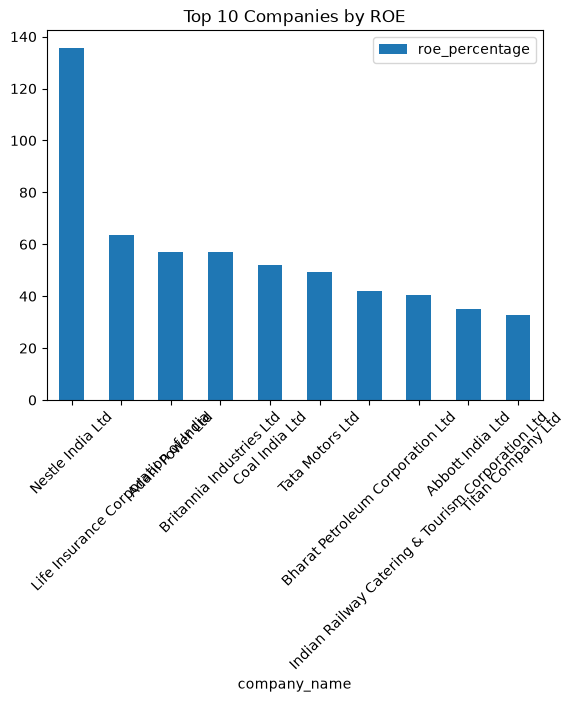

In [7]:
top_roe = merged.sort_values(by="roe_percentage", ascending=False).head(10)

top_roe.plot(x="company_name", y="roe_percentage", kind="bar")
plt.title("Top 10 Companies by ROE")
plt.xticks(rotation=45)
plt.show()

# BY ROCE

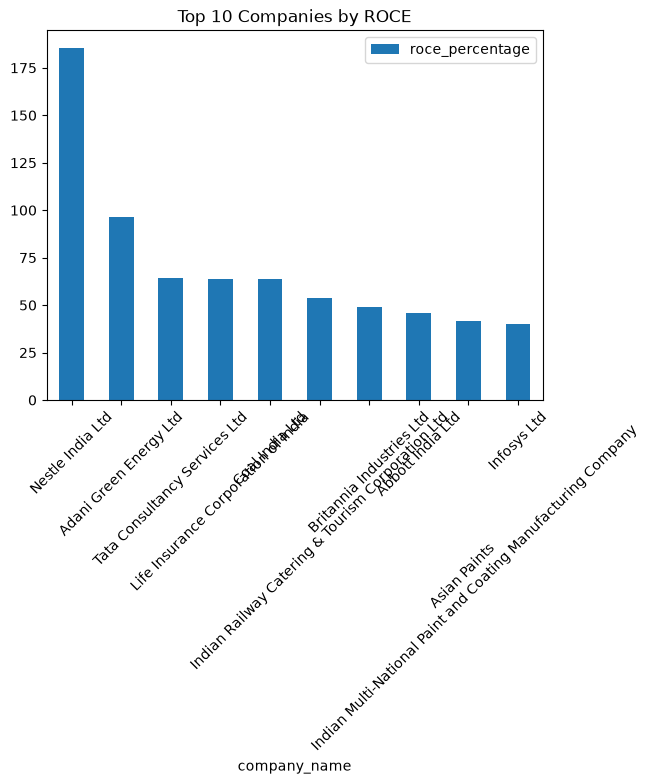

In [8]:
top_roce = merged.sort_values(by="roce_percentage", ascending=False).head(10)

top_roce.plot(x="company_name", y="roce_percentage", kind="bar")
plt.title("Top 10 Companies by ROCE")
plt.xticks(rotation=45)
plt.show()

# MARKET CAP ANALYSIS

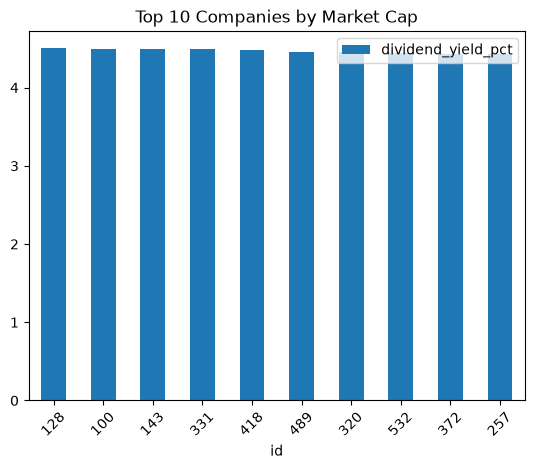

In [10]:
market_cap = pd.read_excel("../data/raw/market_cap.xlsx", header=None)

market_cap.columns = market_cap.iloc[0]
market_cap = market_cap[1:]
market_cap.columns = (
    market_cap.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

market_cap[market_cap.columns[-1]] = pd.to_numeric(
    market_cap[market_cap.columns[-1]], errors='coerce'
)

top_mc = market_cap.sort_values(by=market_cap.columns[-1], ascending=False).head(10)

top_mc.plot(x=market_cap.columns[0], y=market_cap.columns[-1], kind="bar")

plt.title("Top 10 Companies by Market Cap")
plt.xticks(rotation=45)
plt.show()

# PROFIT ANALYSIs

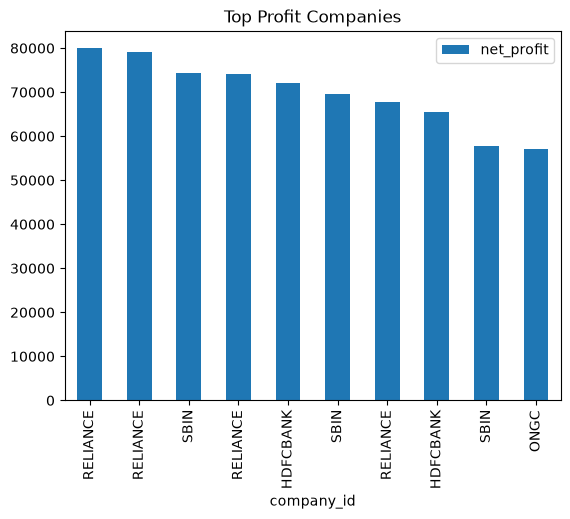

In [11]:
pl = pd.read_sql("SELECT * FROM profitandloss", conn)

pl.columns = pl.columns.str.lower()

pl['net_profit'] = pd.to_numeric(pl['net_profit'], errors='coerce')

top_profit = pl.sort_values(by="net_profit", ascending=False).head(10)

top_profit.plot(x="company_id", y="net_profit", kind="bar")

plt.title("Top Profit Companies")
plt.show()

# STOCK TREND

In [12]:
import pandas as pd

prices = pd.read_excel("../data/raw/stock_prices.xlsx")

print(prices.head())

   id company_id        date  open_price  high_price  low_price  close_price  \
0   1        ABB  2020-01-01     1958.61     2150.53    1835.28      1964.30   
1   2        ABB  2020-02-01     2177.03     2192.92    1931.08      2165.21   
2   3        ABB  2020-03-01     2221.26     2440.28    1995.23      2198.78   
3   4        ABB  2020-04-01     1932.02     2027.44    1740.12      1958.56   
4   5        ABB  2020-05-01     2089.00     2290.96    1878.23      2085.72   

     volume  adjusted_close  
0  26184368         1964.30  
1   1668316         2165.21  
2  20578107         2198.78  
3  14558597         1958.56  
4  44638694         2085.72  


In [13]:
print(prices.head())
print(prices.columns)

   id company_id        date  open_price  high_price  low_price  close_price  \
0   1        ABB  2020-01-01     1958.61     2150.53    1835.28      1964.30   
1   2        ABB  2020-02-01     2177.03     2192.92    1931.08      2165.21   
2   3        ABB  2020-03-01     2221.26     2440.28    1995.23      2198.78   
3   4        ABB  2020-04-01     1932.02     2027.44    1740.12      1958.56   
4   5        ABB  2020-05-01     2089.00     2290.96    1878.23      2085.72   

     volume  adjusted_close  
0  26184368         1964.30  
1   1668316         2165.21  
2  20578107         2198.78  
3  14558597         1958.56  
4  44638694         2085.72  
Index(['id', 'company_id', 'date', 'open_price', 'high_price', 'low_price',
       'close_price', 'volume', 'adjusted_close'],
      dtype='str')


In [18]:
prices.rename(columns={
    "company_name": "temp",
    "company_id": "company_name"
}, inplace=True)

prices.drop(columns=["temp"], inplace=True)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

prices.columns = prices.columns.str.strip().str.lower()

prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
prices["close_price"] = pd.to_numeric(prices["close_price"], errors="coerce")

prices = prices.dropna(subset=["date", "close_price"])
print(prices.head())
print(prices["company_name"].unique()[:10])

   id company_name       date  open_price  high_price  low_price  close_price  \
0   1          ABB 2020-01-01     1958.61     2150.53    1835.28      1964.30   
1   2          ABB 2020-02-01     2177.03     2192.92    1931.08      2165.21   
2   3          ABB 2020-03-01     2221.26     2440.28    1995.23      2198.78   
3   4          ABB 2020-04-01     1932.02     2027.44    1740.12      1958.56   
4   5          ABB 2020-05-01     2089.00     2290.96    1878.23      2085.72   

     volume  adjusted_close  
0  26184368         1964.30  
1   1668316         2165.21  
2  20578107         2198.78  
3  14558597         1958.56  
4  44638694         2085.72  
<StringArray>
[       'ABB', 'ADANIENSOL',   'ADANIENT', 'ADANIGREEN', 'ADANIPORTS',
 'ADANIPOWER',  'AMBUJACEM', 'APOLLOHOSP', 'ASIANPAINT',       'ATGL']
Length: 10, dtype: str


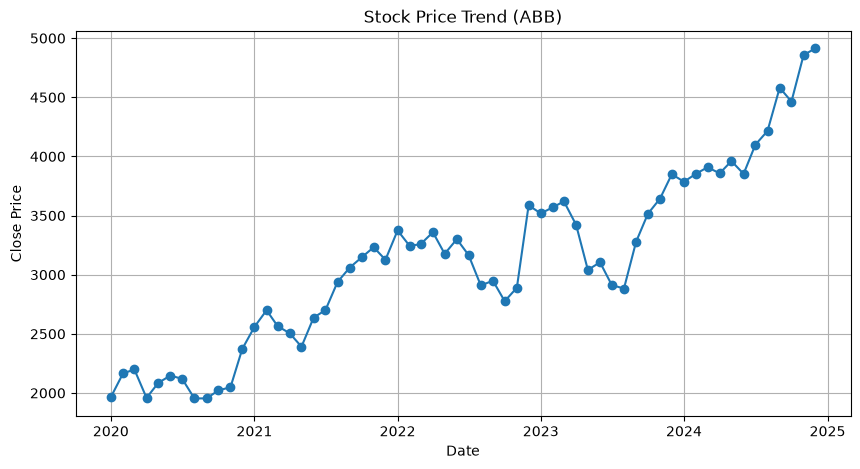

In [17]:
sample = prices[prices["company_name"] == "ABB"]

sample = sample.sort_values("date")

plt.figure(figsize=(10,5))
plt.plot(sample["date"], sample["close_price"], marker='o')

plt.title("Stock Price Trend (ABB)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()

plt.show()

# PROFIT ANALYSIS

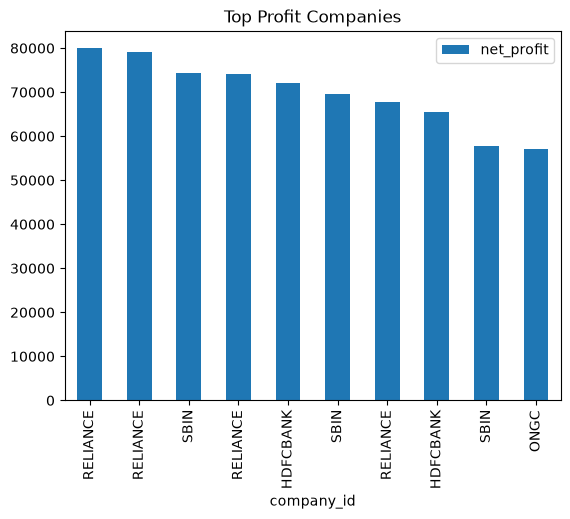

In [ ]:
pl = pd.read_sql("SELECT * FROM profitandloss", conn)

pl.columns = pl.columns.str.lower()

pl['net_profit'] = pd.to_numeric(pl['net_profit'], errors='coerce')

top_profit = pl.sort_values(by="net_profit", ascending=False).head(10)

top_profit.plot(x="company_id", y="net_profit", kind="bar")

plt.title("Top Profit Companies")
plt.show()

##  Final Insights

- Industrial and Energy sectors dominate the dataset in terms of number of companies.

- A small number of companies contribute to a large portion of total market capitalization.

- Companies with high ROE and ROCE indicate better financial efficiency and performance.

- Market cap and financial metrics are unevenly distributed across companies.

- Stock prices show clear trends and fluctuations over time.

- Moving averages help smooth out volatility and reveal long-term trends.

- There is a strong correlation between open, high, low, and close prices.